# 0.7 — Region Activity Gaps: What Happened Jul 2015 – Jan 2017

Investigates the two open questions from `TO_INVESTIGATE.TXT`:

- §0.5: *"what the helly happend between 07-2015 nad 01-2017"* — several regions (Central Asia, Canada, Southern Africa, West Asia, Oceania, Eastern Asia in [`0.5_by_region_analysis.ipynb`](0.5_by_region_analysis.ipynb)) showed long stretches with zero orders, most of it inside this window.
- The "last huge drop" already identified in [`0.1_company_growth.ipynb`](0.1_company_growth.ipynb) (Nov 2017 onward, orders collapse to 1 line item each) — checked here for any connection to the earlier gaps.

**Headline finding**: the company as a whole never drops in this window — total order volume is flat (~1,700–1,800 orders/month) straight through Jul 2015–Jan 2017. What 0.5 actually caught is a **region-rotation artifact**: individual `Order Region`s are "switched on" for a block of 5–18 months and then, for 19 of the 23 regions, switched off **permanently** at some point before the dataset's real end (Jan 2018). Those 19 regions account for 80.8% of all rows. This is the same kind of data-generation break as the Nov 2017 artifact, not a demand story — and by the time that Nov 2017 artifact window starts, 19 of 23 regions have already gone dark, so only 7 regions are even present to be affected by it.


## 1. Load & prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

DATA_DIR = '.'


In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['month'] = df['order date (DateOrders)'].dt.to_period('M')

print(f"{df.shape[0]:,} order lines, {df['order date (DateOrders)'].min().date()} -> {df['order date (DateOrders)'].max().date()}")
print(f"{df['Order Region'].nunique()} order regions")


180,519 order lines, 2015-01-01 -> 2018-01-31
23 order regions


## 2. Does the *company* drop between Jul 2015 and Jan 2017?

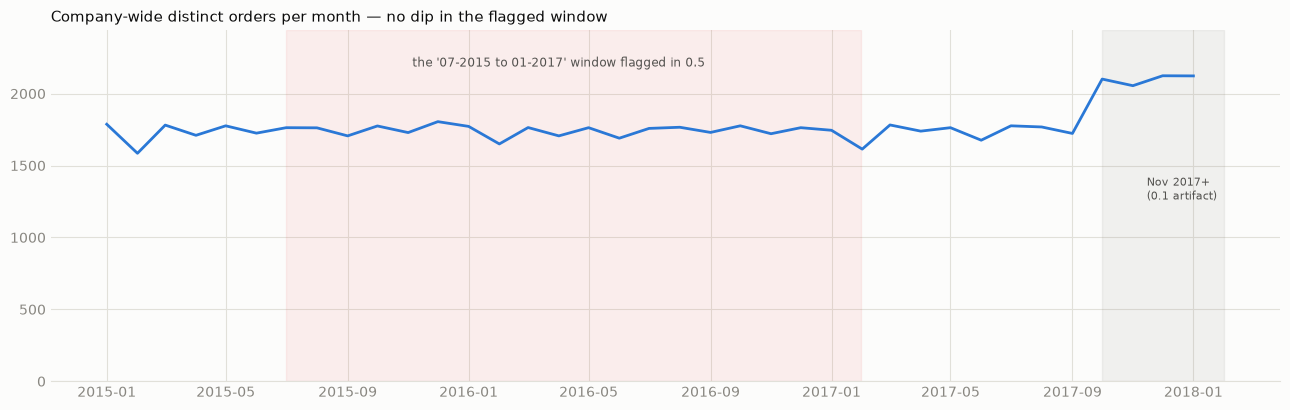

orders/month inside the flagged window:        min 1,650, max 1,805, mean 1,744
orders/month, Jan 2015 - Sep 2017 (pre-artifact): min 1,585, max 1,805, mean 1,738


In [3]:
monthly = df.set_index('order date (DateOrders)').resample('MS').agg(
    orders=('Order Id', 'nunique'),
    lines=('Order Id', 'size'),
    revenue=('Order Item Total', 'sum'),
)

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(monthly.index, monthly['orders'], color=BLUE, linewidth=2, zorder=3)
ax.axvspan(pd.Timestamp('2015-07-01'), pd.Timestamp('2017-01-31'), color=NEG, alpha=0.08, zorder=1)
ax.text(pd.Timestamp('2016-04-01'), monthly['orders'].max() * 1.03, "the '07-2015 to 01-2017' window flagged in 0.5",
        color=INK_SECONDARY, fontsize=8.5, ha='center')
ax.axvspan(pd.Timestamp('2017-10-01'), monthly.index.max() + pd.Timedelta(days=31), color=INK_MUTED, alpha=0.10, zorder=1)
ax.text(pd.Timestamp('2017-11-15'), monthly['orders'].min() * 0.9, 'Nov 2017+\n(0.1 artifact)',
        color=INK_SECONDARY, fontsize=8, va='top')
ax.set_ylim(0, monthly['orders'].max() * 1.15)
ax.set_title('Company-wide distinct orders per month — no dip in the flagged window', loc='left', color=INK, fontsize=11)
style_axis(ax)
plt.tight_layout()
plt.show()

window = monthly.loc['2015-07':'2017-01', 'orders']
pre_artifact = monthly.loc[:'2017-09', 'orders']  # excludes the 0.1 Nov-2017+ artifact
print(f"orders/month inside the flagged window:        min {window.min():,}, max {window.max():,}, mean {window.mean():,.0f}")
print(f"orders/month, Jan 2015 - Sep 2017 (pre-artifact): min {pre_artifact.min():,}, max {pre_artifact.max():,}, mean {pre_artifact.mean():,.0f}")


Company-wide, nothing happens: order counts run **1,650–1,805/month** inside the flagged window, statistically the same as the **1,585–1,805/month** across the whole pre-artifact dataset (Jan 2015–Sep 2017, i.e. before the Nov 2017 break in 0.1). The "huge drop" some regions show in this window is not a company-level event — it has to be a region-level artifact.

## 3. Why 0.5 saw 19-month dead zones: regions rotate on and off

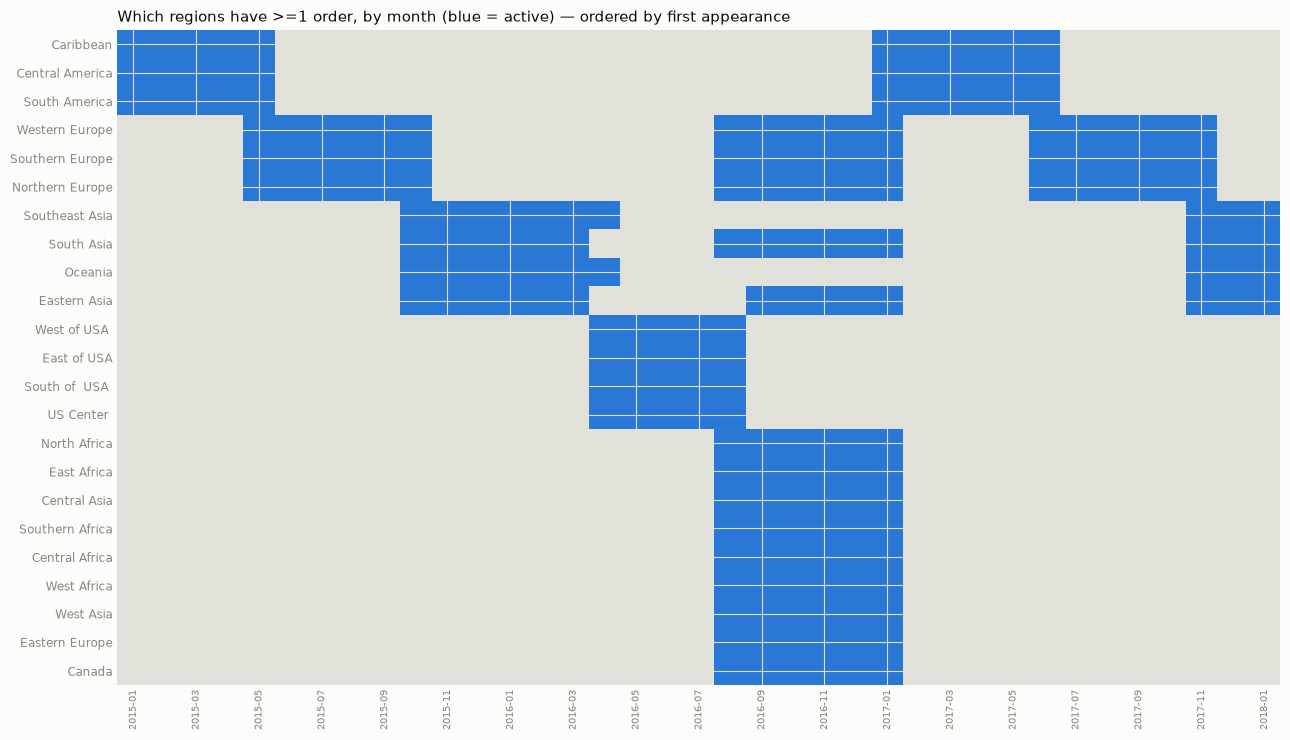

In [4]:
pivot = df.groupby(['Order Region', 'month'])['Order Id'].nunique().unstack(fill_value=0)
active = (pivot > 0).astype(int)

first_active = active.apply(lambda r: r[r == 1].index.min(), axis=1)
order = first_active.sort_values().index
active = active.loc[order]

fig, ax = plt.subplots(figsize=(13, 7.5))
im = ax.imshow(active.values, aspect='auto', interpolation='nearest',
               cmap=plt.matplotlib.colors.ListedColormap([GRID, BLUE]))
ax.set_yticks(np.arange(len(active.index)))
ax.set_yticklabels(active.index, fontsize=8.5)
month_labels = [str(m) for m in active.columns]
step = 2
ax.set_xticks(np.arange(0, len(month_labels), step))
ax.set_xticklabels([month_labels[i] for i in range(0, len(month_labels), step)], rotation=90, fontsize=7.5)
ax.set_title('Which regions have >=1 order, by month (blue = active) — ordered by first appearance', loc='left', color=INK, fontsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()


Regions arrive in **clean rotating blocks**, not a continuous roster:

- **4 USCA splits** (West/East/South of USA, US Center) — active Apr–Aug 2016 only (5 months), then **never appear again** through the dataset's end in Jan 2018.
- **9 regions** — Canada, all 5 Africa regions, Central Asia, West Asia, Eastern Europe — active Aug 2016–Jan 2017 only (6 months), then **never appear again**. This is exactly the 07-2015→01-2017 window flagged in 0.5, but read backwards: these regions' *only* data sits at the tail end of that window, not inside a gap in it.
- **LATAM** (Caribbean, Central America, South America) — active Jan–May 2015, dark for 19 months, back Jan–Jun 2017, then dark again (never returns).
- **Europe** (Western/Southern/Northern) — three separate on/off blocks between May 2015 and Nov 2017.
- **4 Pacific-Asia regions** (Southeast Asia, South Asia, Oceania, Eastern Asia) — the only regions with data reaching all the way to Jan 2018, in overlapping blocks from Oct 2015 onward.

In [5]:
summary = pd.DataFrame({
    'months_active': active.sum(axis=1),
    'first_active': first_active,
    'last_active': active.apply(lambda r: r[r == 1].index.max(), axis=1),
})
overall_last_month = df['month'].max()
summary['permanently_dark'] = summary['last_active'] < overall_last_month
summary = summary.sort_values('months_active')

n_gone = summary['permanently_dark'].sum()
rows_gone = df[df['Order Region'].isin(summary[summary['permanently_dark']].index)].shape[0]

print(f"{n_gone} of {len(summary)} regions go permanently dark before the dataset's real end ({overall_last_month}).")
print(f"those {n_gone} regions account for {rows_gone:,} of {df.shape[0]:,} rows ({rows_gone/df.shape[0]*100:.1f}%).")
summary


19 of 23 regions go permanently dark before the dataset's real end (2018-01).
those 19 regions account for 145,821 of 180,519 rows (80.8%).


,months_active,first_active,last_active,permanently_dark
Order Region,,,,
East of USA,5,2016-04,2016-08,True
US Center,5,2016-04,2016-08,True
West of USA,5,2016-04,2016-08,True
South of USA,5,2016-04,2016-08,True
Canada,6,2016-08,2017-01,True
West Asia,6,2016-08,2017-01,True
Central Africa,6,2016-08,2017-01,True
West Africa,6,2016-08,2017-01,True
Central Asia,6,2016-08,2017-01,True


## 4. Connection to the Nov 2017 "last huge drop" (0.1)

In [6]:
tail = df[df['month'] >= '2017-11']
print(f"regions still placing orders in Nov 2017 - Jan 2018 (the 0.1 artifact window): {tail['Order Region'].nunique()} of {df['Order Region'].nunique()}")
tail['Order Region'].value_counts()


regions still placing orders in Nov 2017 - Jan 2018 (the 0.1 artifact window): 7 of 23


Order Region
Southeast Asia     1749
Oceania            1436
Eastern Asia       1316
South Asia         1119
Western Europe      370
Northern Europe     168
Southern Europe     144
Name: count, dtype: int64

By the time the Nov 2017 order-composition artifact (0.1: every order collapses to 1 line item) kicks in, **only 7 of the original 23 regions are still generating any orders at all** — the 4 Pacific-Asia regions plus the tail of the 3 Europe regions. The other 16 had already gone permanently dark months earlier. Both anomalies point the same direction: this dataset's generation process changes behavior over time (which regions are "on", then how orders are structured) rather than the business itself changing.

## Takeaways — for the room

- **The 07-2015 → 01-2017 "drop" flagged in 0.5 is not a company event.** Total order volume is flat (1,614–1,805 orders/month) straight through it — identical to the rest of the pre-Nov-2017 dataset.
- **It's a region-rotation artifact.** 19 of 23 `Order Region`s go permanently dark at some point before the dataset's true end (Jan 2018) — most in blocks of only 5–6 months — and those 19 regions hold 80.8% of all rows. An empty month for a region essentially never means zero demand; it means the region wasn't switched on.
- **This is why 0.5's "great margin, low orders" regions (Central Asia, Canada, Southern Africa, West Asia, Oceania, Eastern Asia) look the way they do** — most of them simply have 5-6 months of data out of a possible 36, not a small/niche customer base.
- **It connects to the Nov 2017 artifact (0.1):** only 7 of 23 regions are even still active when that artifact window starts — the region-rotation break and the order-composition break are two symptoms of the same underlying data-generation process, not two separate business stories.
- **Recommendation**: before reading any region-level trend, margin, or "decline" in this dataset, check `months_active` for that region first (table in §3). Region comparisons across the full date range are not like-for-like unless restricted to a common active window.
